In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import sys
sys.path.append("../discretized-causalpfn")
from discretize import DataDiscretizer
from inference import DiscreteCausalPFN

In [2]:
dict(i : [i ** 2] for i in range(10))

SyntaxError: invalid syntax (4075475850.py, line 1)

In [ ]:
1 + 1

In [5]:
## Synthetic data generation
data_name = "vahid-linear"
np.random.seed(42)
n, d = 500, 3
X = np.random.normal(1, 1, size=(n, d)).astype(np.float32)
T = (X[:, 0] - X[:, 1] + 2 * X[:, 2] + 2 + np.random.normal(0, 3, size=n)).astype(np.float32)
T = T - T.min() # Rescale
T = T / T.max() # Rescale
Y = (3 * X[:, 0] + X[:, 1] - 0.5 * X[:, 2] + 3 * T + np.random.normal(0, 2, size=n)).astype(np.float32)
def drf(t): return 3.5 + 3 * t # true dose-response function

In [6]:
uniform_discretizer = DataDiscretizer("uniform")
N_DISC = 5
T_discrete, T_vals = uniform_discretizer.discretize_treatment(T, N_DISC)

model = DiscreteCausalPFN(
    comparison_method="sequential",
    N_DISC=N_DISC,
    device="cpu",
    verbose="True"
)

In [48]:
model.predict_epos(
    X, T_discrete, Y, T_vals
)

Predicting CEPO: 100%|██████████| 134/134 [00:00<00:00, 648.61it/s]


{np.float64(0.0): [np.float32(3.9351153)],
 np.float64(0.25): [np.float32(4.5191617), np.float32(4.8986106)],
 np.float64(0.5): [np.float32(5.1529055), np.float32(5.249727)],
 np.float64(0.75): [np.float32(5.4141326), np.float32(5.6715307)],
 np.float64(1.0): [np.float32(8.149522)]}

In [49]:
model = DiscreteCausalPFN(
    comparison_method="all",
    N_DISC=N_DISC,
    device="cpu",
    verbose="True"
)

In [51]:
output = model.predict_epos(
    X, T_discrete, Y, T_vals
)

Predicting CEPO: 100%|██████████| 134/134 [00:00<00:00, 684.12it/s]


In [57]:
10_000

10000

## Get T values in the EPO_df script output

In [ ]:
import pandas as pd
import sys
sys.path.append("../../..")
import numpy as np
import torch
import datetime

from src.causalpfn.causal_estimator import CausalEstimator

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Main hyperparameter
N_DISC_VALUES = [3]

# Discretization function
def discretize_treatment(T: np.ndarray, N: int) -> tuple[np.ndarray, np.ndarray]:
    """Returns quantile method discretized version of T. Assumes range of T is [0, 1].

    Args:
        T (np.ndarray): The raw treatment data 
        N (int): The number of bins (equiv to the number of discrete treatment values)

    Returns:
        np.ndarray: The discretized treatment data (expected outcomes)
        np.ndarray: The discretized treatment values
    """
    T_discrete = np.zeros(T.shape)
    T_vals = np.zeros((N,))
    bin_edges = np.percentile(T, np.linspace(0, 100, N + 1))
    for i in range(len(bin_edges) - 1):
        left_edge = bin_edges[i]
        right_edge = bin_edges[i + 1]
        ids = (T >= left_edge) & (T <= right_edge)
        avg = np.mean(T[ids])
        T_discrete[ids] = avg
        T_vals[i] = avg

    return T_discrete, T_vals

In [ ]:
## Synthetic data generation
data_name = "vahid-linear"

np.random.seed(42)
n, d = 2000, 3
X = np.random.normal(1, 1, size=(n, d)).astype(np.float32)
T = (X[:, 0] - X[:, 1] + 2 * X[:, 2] + 2 + np.random.normal(0, 3, size=n)).astype(np.float32)
T = T - T.min() # Rescale
T = T / T.max() # Rescale
Y = (3 * X[:, 0] + X[:, 1] - 0.5 * X[:, 2] + 3 * T + np.random.normal(0, 2, size=n)).astype(np.float32)
def drf(t): return 3.5 + 3 * t # true dose-response function

df = pd.concat([
    pd.DataFrame(data=X, columns=["x1", "x2", "x3"]), 
    pd.DataFrame(data=T, columns=["T"]), 
    pd.DataFrame(data=Y, columns=["Y"])
    ], axis=1)

## Main inference loop
list_of_epos = [] # [(N_DISC, epos)], epos = [(mu_t0, mu_t1), (mu_t1, mu_t2), ... ]
for N_DISC in N_DISC_VALUES:
    print(f"N_DISC: {N_DISC}")
    T_discrete, T_vals = discretize_treatment(T, N_DISC)
    discrete_treatment_levels = T_vals
    epos = []
    for i, t in enumerate(discrete_treatment_levels[:-1]):
        # focus on two neighboring treatment levels and convert to binary T = 0, 1 values 
        t0, t1 = discrete_treatment_levels[i], discrete_treatment_levels[i + 1]
        ids = (np.abs(T_discrete - t0) < 1e-4) | (np.abs(T_discrete - t1) < 1e-4)
        T_temp = np.where(np.abs(T_discrete[ids] - t0) < 1e-4, 0, 1).astype(np.float32)
        X_temp = X[ids].astype(np.float32)
        Y_temp = Y[ids].astype(np.float32)
        # to predict cepo
        X_context = X_temp 
        t_context = T_temp
        y_context = Y_temp
        X_query = X_temp 
        t_all_ones = np.ones(X_query.shape[0], dtype=X_query.dtype)
        t_all_zeros = np.zeros(X_query.shape[0], dtype=X_query.dtype)
        causalpfn_cepo = CausalEstimator(
            device=device,
            verbose=True
        )
        causalpfn_cepo.fit(X_temp, T_temp, Y_temp)
        mu_vals = causalpfn_cepo._predict_cepo(
            X_context=X_context,
            t_context=t_context,
            y_context=y_context,
            X_query=np.concatenate([X_query, X_query], axis=0),
            t_query=np.concatenate([t_all_zeros, t_all_ones], axis=0),
            temperature=causalpfn_cepo.prediction_temperature,
        )
        mu_0 = (mu_vals[: X_query.shape[0]]).mean()
        mu_1 = (mu_vals[X_query.shape[0] :]).mean()
        epos.append((mu_0, mu_1))
    list_of_epos.append((N_DISC, epos))

N_DISC: 3


Predicting CEPO: 100%|██████████| 2666/2666 [00:05<00:00, 498.33it/s]


In [ ]:
multi_indices = pd.MultiIndex.from_tuples(
    [(N, i) for N in N_DISC_VALUES for i in range(N)],
    names=["N_DISC", "treatment_value_idx"]
)
cols = ["T", "EPOs_1","EPOs_2", "true_effect"]
data = []


[(3,
  [(np.float32(4.414575), np.float32(4.9970345)),
   (np.float32(5.121178), np.float32(5.4377427))])]

In [ ]:
list_of_epos

[(3,
  [(np.float32(4.414575), np.float32(4.9970345)),
   (np.float32(5.121178), np.float32(5.4377427))])]

In [ ]:
T_vals

array([0.34016383, 0.5104093 , 0.68598545])

## Debt-loss dataset RMSE weirdness (11-18-2025)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# RMSE function
def calculate_rmse(y_pred, y_true):
    result = np.mean(np.power(y_pred - y_true, 2))
    result = np.sqrt(result)

    return result

In [ ]:
df_debt = pd.read_csv(
    "..\output\quantile_EPO_df_debt-loss_11-18_11h37m.csv",
    index_col=[0, 1]
)
df = df_debt
data_name = "debt"
N_max = df.index[-1][0]

In [ ]:
df_2 = df.loc[[2]]
df_2

EPOs_1    EPOs_2  true_effect
N_DISC treatment_value_idx                                 
2      0                         NaN  0.403589          0.0
       1                    0.565891       NaN          1.0

In [ ]:
calculate_rmse(np.array([.403589, .565891]), np.array([0, 1]))

np.float64(0.4191268929584452)

In [ ]:
df_3 = df.loc[[3]]
df_3.head()

EPOs_1    EPOs_2  true_effect
N_DISC treatment_value_idx                                 
3      0                         NaN  0.465731      0.00000
       1                    0.592238  0.372021      0.47941
       2                    0.525696       NaN      1.00000

In [ ]:
np.mean(df_3.loc[(3, 1), ["EPOs_1", "EPOs_2"]])

np.float64(0.4821294993162155)

In [ ]:
calculate_rmse(np.array([.465731, .482129, .525696]), np.array([0, .47941, 1]))

np.float64(0.3837868513198439)

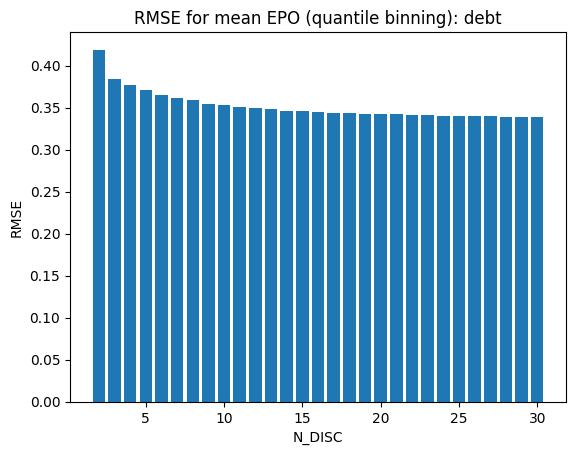

In [ ]:
# RMSE calculation on the average EPO
rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    y_true = df_N["true_effect"].values
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO (quantile binning): {data_name}")

plt.show()

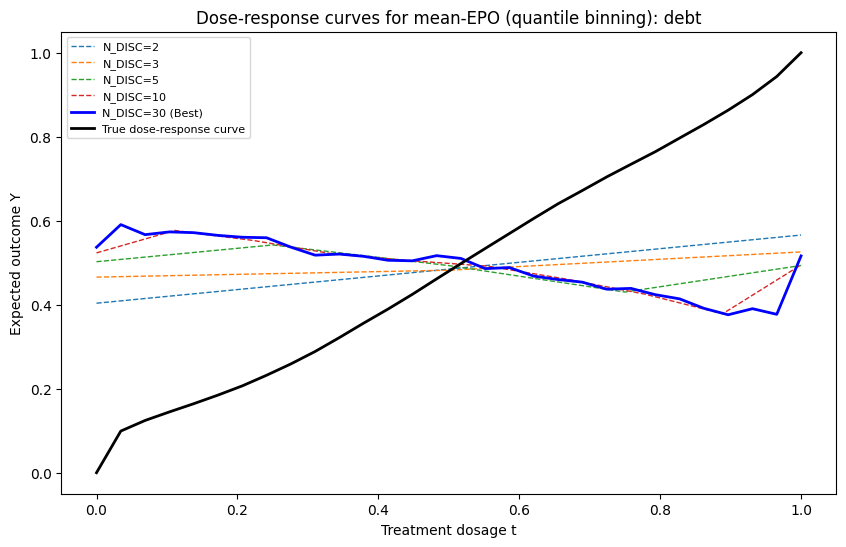

In [ ]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 3, 5, 10, 30]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    # Fill first and last values 
    df_N.loc[(N_DISC, 0), "EPOs_1"] = df_N.loc[(N_DISC, 0), "EPOs_2"]
    df_N.loc[(N_DISC, N_DISC - 1), "EPOs_2"] = df_N.loc[(N_DISC, N_DISC - 1), "EPOs_1"]
    # Average and calculate RMSE aggainst true_effect
    y_pred = df_N[["EPOs_1", "EPOs_2"]].mean(axis=1).values
    if rmse_df.loc[N_DISC, "RMSE"] == rmse_df.min().values: # emphasize best prediction
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best)", c="blue", zorder=14)
    else:
        plt.plot(np.linspace(0.0, 1.0, N_DISC), y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve (approximated by df.loc[[30]]["true_effect"])
y_true = df.loc[[30]]["true_effect"].values
t_mesh = np.linspace(0, 1, len(y_true))
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves for mean-EPO (quantile binning): {data_name}")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)

plt.show()

## Debt-loss dataset sanity check (11-17-2025)

In [ ]:
# Debt-loss dataset looking weird; let's check
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(
    "..\output\EPO_df_debt-loss_11-17_14h2m.csv",
    index_col=[0, 1]
)
df.head()

EPOs_1    EPOs_2  true_effect
N_DISC treatment_value_idx                                 
2      0                         NaN  0.400863      0.00000
       1                    0.563340       NaN      1.00000
3      0                         NaN  0.340857      0.00000
       1                    0.524194  0.450433      0.47941
       2                    0.665055       NaN      1.00000

In [ ]:
df.loc[[10]]

EPOs_1    EPOs_2  true_effect
N_DISC treatment_value_idx                                 
10     0                         NaN  0.427084     0.000000
       1                    0.583422  0.507264     0.149175
       2                    0.597637  0.513603     0.218145
       3                    0.596407  0.498458     0.310821
       4                    0.566479  0.455323     0.420720
       5                    0.542770  0.419859     0.538000
       6                    0.513214  0.370862     0.651237
       7                    0.486436  0.327479     0.750598
       8                    0.505142  0.360015     0.855259
       9                    0.670558       NaN     1.000000

In [ ]:
df.loc[[10]]["EPOs_2"] - df.loc[[10]]["EPOs_1"] # Negative ATE

N_DISC  treatment_value_idx
10      0                           NaN
        1                     -0.076158
        2                     -0.084034
        3                     -0.097949
        4                     -0.111156
        5                     -0.122911
        6                     -0.142352
        7                     -0.158956
        8                     -0.145127
        9                           NaN
dtype: float64

In [ ]:
df_N.loc[(10, 0), "EPOs_2"]

np.float64(0.4270842671394348)

In [ ]:
# Positive ATE when subintervals shifted
N = 10
df_N = df.loc[[N]]
ates = []
for i in range(len(df_N) - 1):
    mu_0 = df_N.loc[(N, i), "EPOs_2"]
    mu_1 = df_N.loc[(N, i + 1), "EPOs_1"]
    ate = mu_1 - mu_0
    ates.append(ate)
ates

[np.float64(0.1563376784324646),
 np.float64(0.0903734564781189),
 np.float64(0.08280384540557861),
 np.float64(0.06802129745483404),
 np.float64(0.08744663000106817),
 np.float64(0.09335446357727056),
 np.float64(0.11557421088218689),
 np.float64(0.17766219377517706),
 np.float64(0.3105432987213135)]

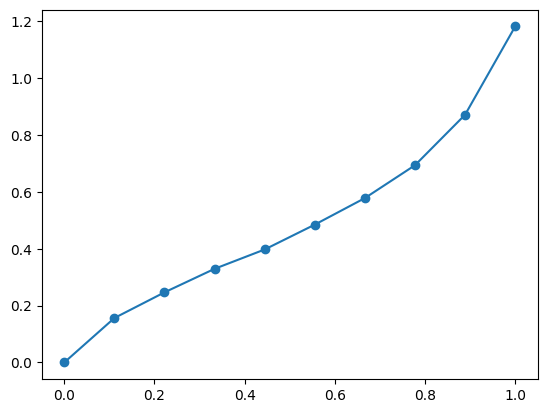

In [ ]:
ate_calc = [sum(ates[:i]) for i in range(N)]

plt.plot(np.linspace(0, 1, len(ate_calc)), ate_calc, '-o')

In [ ]:
# Looks right!